<a href="https://colab.research.google.com/github/AgungPramono/Android-Password-Store/blob/api_30_support/prediksi_bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                   Open          High           Low  \
Date                                                                  
2018-01-01 00:00:00+00:00  14112.200195  14112.200195  13154.700195   
2018-01-02 00:00:00+00:00  13625.000000  15444.599609  13163.599609   
2018-01-03 00:00:00+00:00  14978.200195  15572.799805  14844.500000   
2018-01-04 00:00:00+00:00  15270.700195  15739.700195  14522.200195   
2018-01-05 00:00:00+00:00  15477.200195  17705.199219  15202.799805   

                                  Close       Volume  
Date                                                  
2018-01-01 00:00:00+00:00  13657.200195  10291200000  
2018-01-02 00:00:00+00:00  14982.099609  16846600192  
2018-01-03 00:00:00+00:00  15201.000000  16871900160  
2018-01-04 00:00:00+00:00  15599.200195  21783199744  
2018-01-05 00:00:00+00:00  17429.500000  23840899072  


<Figure size 640x480 with 0 Axes>

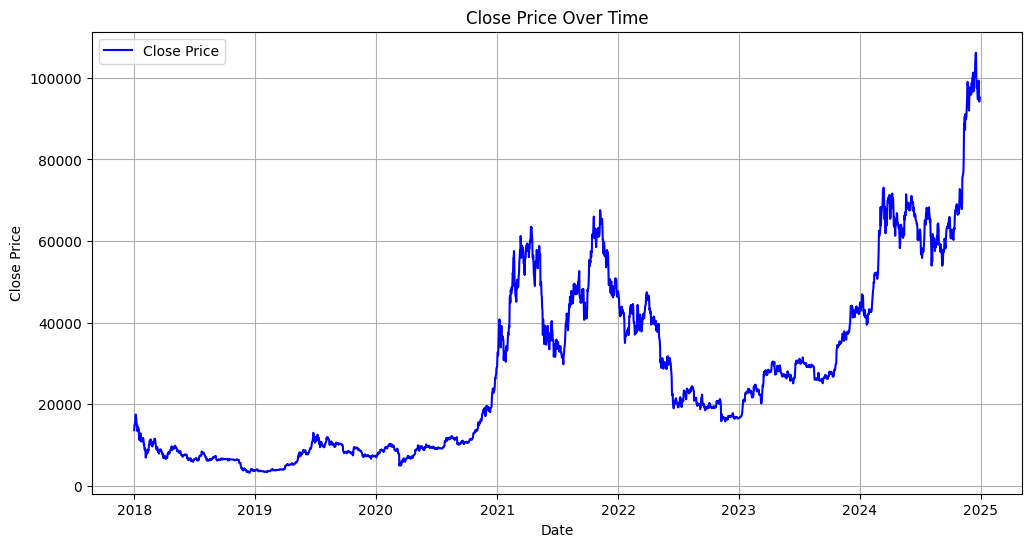

Num GPUs Available:  0
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0291
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0019
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0015
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0013
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0010
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 9.5838e-04
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 8.1820e-04
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 8.9772e-04
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 8.5352e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Mean Squared Error (MSE): 0.0007165074405351876
R-squared (R2): 0.9798555683600851

Data Hasil Prediksi dan Actual:

     Actual Close Price  Predicted Close Price
0          26049.556641           29611.056641
1          26096.205078           29119.572266
2 

<Figure size 640x480 with 0 Axes>

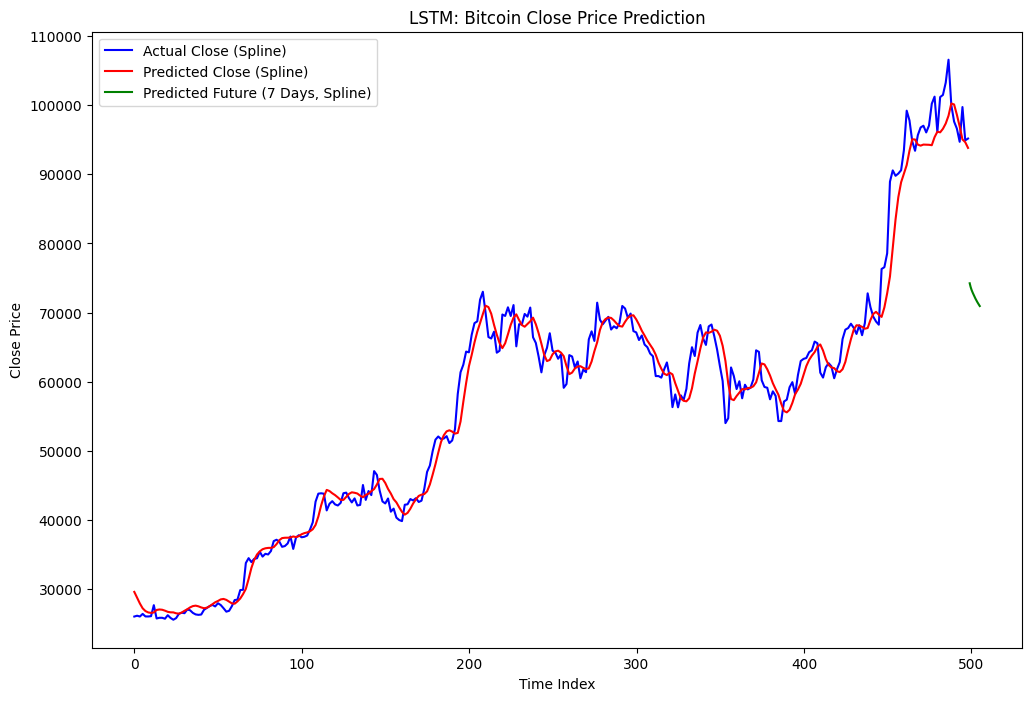

In [2]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,Input
from scipy.interpolate import make_interp_spline

# Fungsi untuk preprocessing data
def preprocess_data(data):
    """Preprocess data dengan normalisasi dan memilih kolom relevan."""
    data = data[['Open', 'High', 'Low', 'Close', 'Volume']]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, data, scaler

# Fungsi untuk membagi data menjadi sequence untuk LSTM
def split_data(scaled_data, sequence_length=60):
    """Membagi data menjadi sequence untuk training dan testing (LSTM)."""
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i, :-1])  # Input data untuk LSTM (sequence of 60 timesteps)
        y.append(scaled_data[i, 3])  # Target: Close price
    X, y = np.array(X), np.array(y)
    return train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Fungsi untuk membuat spline pada data
def create_spline(x, y, num_points=300):
    """Membuat spline untuk data yang lebih halus."""
    x_new = np.linspace(x.min(), x.max(), num_points)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Fungsi untuk membuat prediksi masa depan
def predict_future(model, last_scaled, scaler, raw_data, days):
    """Membuat prediksi masa depan berdasarkan model LSTM."""
    predictions = []

    # Loop untuk prediksi hari demi hari
    for _ in range(days):
        # Melakukan prediksi
        next_pred_scaled = model.predict(last_scaled)
        predicted_value = next_pred_scaled[0, 0]  # Ambil nilai prediksi pertama
        predictions.append(predicted_value)

        # Update last_scaled dengan menambahkan prediksi terbaru
        predicted_value_reshaped = np.reshape(predicted_value, (1, 1, 1))  # Ubah bentuk prediksi agar sesuai

        # Membuat array prediksi dengan dimensi yang sesuai (4 fitur)
        predicted_value_expanded = np.repeat(predicted_value_reshaped, 4, axis=2)  # Ulangi prediksi untuk 4 fitur

        # Gabungkan last_scaled dengan prediksi yang telah diperluas
        new_scaled = np.concatenate((last_scaled[:, 1:, :], predicted_value_expanded), axis=1)  # Update sequence
        last_scaled = new_scaled

    # Membuat data untuk masa depan
    future_scaled = np.column_stack([
        np.full((days, 1), raw_data['Open'].iloc[-1]),  # Open value
        np.full((days, 1), raw_data['High'].iloc[-1]),  # High value
        np.full((days, 1), raw_data['Low'].iloc[-1]),   # Low value
        np.array(predictions).reshape(-1, 1),           # Predicted values
        np.full((days, 1), raw_data['Volume'].iloc[-1]) # Volume value
    ])

    # Menggunakan scaler untuk mengubah nilai yang telah diprediksi ke harga asli
    future_prices = scaler.inverse_transform(future_scaled)[:, 3]  # Mengambil kolom prediksi

    return future_prices


# Fungsi utama untuk plotting hasil
def plot_results(data, y_test_actual, y_pred_actual, future_prices, days):
    """Plot hasil aktual, prediksi, dan prediksi masa depan."""
    x_actual = np.arange(len(data.index[-len(y_test_actual):]))
    x_future = np.arange(len(data.index[-len(y_test_actual):]), len(data.index[-len(y_test_actual):]) + days)

    x_actual_smooth, y_test_smooth = create_spline(x_actual, y_test_actual)
    x_actual_smooth_pred, y_pred_smooth = create_spline(x_actual, y_pred_actual)
    x_future_smooth, future_prices_smooth = create_spline(x_future, future_prices)

    plt.figure(1)
    plt.figure(figsize=(12, 8))
    plt.plot(x_actual_smooth, y_test_smooth, label="Actual Close (Spline)", color='blue')
    plt.plot(x_actual_smooth_pred, y_pred_smooth, label="Predicted Close (Spline)", color='red', linestyle='-')
    plt.plot(x_future_smooth, future_prices_smooth, label=f"Predicted Future ({days} Days, Spline)", color='green', linestyle='-')

    plt.title(f"LSTM: Bitcoin Close Price Prediction")
    plt.xlabel("Time Index")
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()

# Fungsi untuk plotting kolom Close
def plot_close_column(data):
    plt.figure(1)
    """Plot kolom Close dari data historis."""
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], label='Close Price', color='blue')
    plt.title('Close Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

# Mengambil data dari Yahoo Finance
symbol = 'BTC-USD'
start_date = "2018-01-01"
end_date = "2024-12-29"
data = yf.Ticker(symbol).history(start=start_date, end=end_date)
del data['Dividends']
del data['Stock Splits']
print(data.head())

# Plot kolom Close
plot_close_column(data)

# Preprocessing data
scaled_data, raw_data, scaler = preprocess_data(data)

# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = split_data(scaled_data)

import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Membangun model LSTM
timesteps = 10  # Jumlah langkah waktu
features = 4   # Jumlah fitur (misalnya suhu dan kelembapan)

model = Sequential()
model.add(Input(shape=(timesteps, features)))  # Input shape = (10, 2)
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output layer (Close Price)

model.compile(optimizer='adam', loss='mean_squared_error')

# Melatih model LSTM
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Prediksi dengan data testing
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

# Inverse transform untuk y_test dan y_pred
y_test_with_others = np.column_stack([
    np.full_like(y_test, raw_data['Open'].iloc[-1]),
    np.full_like(y_test, raw_data['High'].iloc[-1]),
    np.full_like(y_test, raw_data['Low'].iloc[-1]),
    y_test.reshape(-1, 1),
    np.full_like(y_test, raw_data['Volume'].iloc[-1])
])
y_test_actual = scaler.inverse_transform(y_test_with_others)[:, 3]

y_pred_with_others = np.column_stack([
    np.full_like(y_pred, raw_data['Open'].iloc[-1]),
    np.full_like(y_pred, raw_data['High'].iloc[-1]),
    np.full_like(y_pred, raw_data['Low'].iloc[-1]),
    y_pred.reshape(-1, 1),
    np.full_like(y_pred, raw_data['Volume'].iloc[-1])
])
y_pred_actual = scaler.inverse_transform(y_pred_with_others)[:, 3]

# Menampilkan data hasil prediksi dan actual
df_results = pd.DataFrame({
    'Actual Close Price': y_test_actual,
    'Predicted Close Price': y_pred_actual
})
pd.set_option('display.max_rows', None)
print("\nData Hasil Prediksi dan Actual:\n")
print(df_results)

# Prediksi 100 hari ke depan
days = 7
last_scaled = scaled_data[-60:].reshape(1, 75, 4)  # Ambil 60 hari terakhir sebagai input
future_prices = predict_future(model, last_scaled, scaler, raw_data, days)
for i, price in enumerate(future_prices, 1):
    print(f"Day {i}: {price}")

# Plot hasil
plot_results(data, y_test_actual, y_pred_actual, future_prices, days)


